In [20]:
import numpy as np
import matplotlib.pyplot as plt

In [21]:
# Param
C_D0 = 0.025
K_INDUCED = 0.045
W = 150
RHO = 1.225
S_WING = 1.0

Z_SW = 4000.0
H_SW = 1500.0

GAMMA_MIN = np.deg2rad(-45)
GAMMA_MAX = np.deg2rad(-2.0)
DT = 0.5

In [22]:
# Best-Glider
CL_STAR = np.sqrt(C_D0 / K_INDUCED)
CD_STAR = C_D0 + K_INDUCED*CL_STAR**2
LD_MAX = CL_STAR/CD_STAR
GAMMA_STAR = -np.arctan2(1, LD_MAX)
V_STAR = np.sqrt(2*W*np.cos(abs(GAMMA_STAR)) / (RHO*S_WING*CL_STAR))

GAMMA_MAX = GAMMA_STAR

print(f'(L/D)_max = {LD_MAX:.4f}')
print(f'gamma* = {np.rad2deg(GAMMA_STAR):.4f}')
print(f'v* = {V_STAR:.4f}')

(L/D)_max = 14.9071
gamma* = -3.8378
v* = 18.1060


In [23]:
def glide_speed(gamma):
    gamma = float(np.clip(gamma, GAMMA_MIN, GAMMA_MAX))
    tan_g = np.tan(abs(gamma))
    disc = tan_g**2 - 4.0*K_INDUCED*C_D0
    CL = CL_STAR if disc < 0 else max(
        (tan_g - np.sqrt(disc)) / (2.0*K_INDUCED), 0.01
    )
    return float(np.sqrt(2*W*np.cos(abs(gamma)) / (RHO*S_WING*CL)))

In [24]:
def simulate_glide(gamma_fn, z_sw=Z_SW, h_sw=H_SW, dt=DT):
    if not callable(gamma_fn):
        gamma_val = float(gamma_fn)
        gamma_fn = lambda z, h: gamma_val

    t_arr, z_arr, h_arr, g_arr = [0.0], [z_sw], [h_sw], []

    t, z, h = 0.0, z_sw, h_sw
    while h > 1e-3:
        # gamma = float(np.clip(gamma_fn(z, h), GAMMA_MIN, GAMMA_MAX))
        gamma = np.clip(gamma_fn(z, h), GAMMA_MIN, GAMMA_MAX)
        v = glide_speed(gamma)
        g_arr.append(gamma)

        z += v*np.cos(abs(gamma))*dt
        h = max(h + v*np.sin(gamma)*dt, 0.0)
        t += dt

        t_arr.append(t)
        z_arr.append(z)
        h_arr.append(h)

    g_arr.append(gamma)

    return {
        't': np.array(t_arr),
        'z': np.array(z_arr),
        'h': np.array(h_arr),
        'gamma': np.array(g_arr),
    }

In [25]:
range_analytical = H_SW * LD_MAX
z_final_analytical = Z_SW + range_analytical

print('=== Analytical Max Range ===')
print(f'Analytical Range: {range_analytical:.2f}')
print(f'Final z: {z_final_analytical:.2f}')

# Simulated at constant gamma*
traj_analytial = simulate_glide(GAMMA_STAR)
range_simulated = traj_analytial['z'][-1] - Z_SW

print(f'Siulated range: {range_simulated:.2f}')
print(f'Error: {abs(range_simulated - range_analytical):.2f}')

=== Analytical Max Range ===
Analytical Range: 22360.68
Final z: 26360.68
Siulated range: 22365.00
Error: 4.32


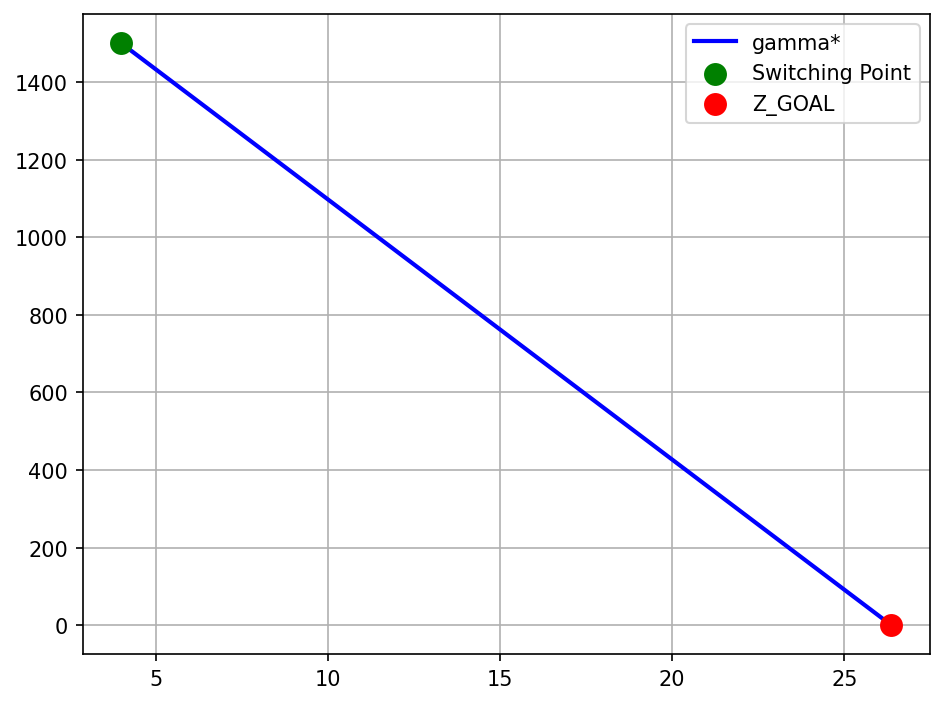

In [26]:
fig = plt.figure(dpi=150)
plt.plot(traj_analytial['z']/1000, traj_analytial['h'], 'b', lw=2, label=f'gamma*')
plt.scatter([Z_SW/1000], [H_SW], color='green', s=100, zorder=6, label=f'Switching Point')
plt.scatter([traj_analytial['z'][-1]/1000], [0], color='red', s=100, zorder=6, label=f'Z_GOAL')
plt.legend()
plt.grid()
plt.tight_layout()

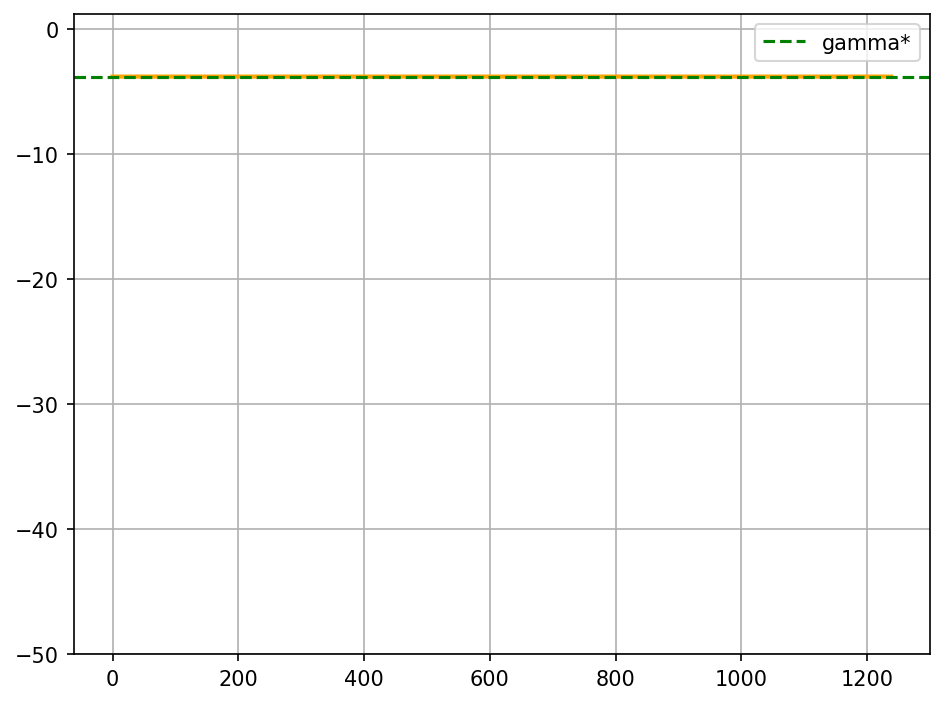

In [27]:
fig = plt.figure(dpi=150)
plt.plot(traj_analytial['t'], np.degrees(traj_analytial['gamma']), color='orange', lw=2)
plt.axhline(np.degrees(GAMMA_STAR), color='green', ls='--', lw=1.5, label=f'gamma*')
plt.ylim([np.rad2deg(GAMMA_MIN)-5, np.rad2deg(GAMMA_MAX)+5])
plt.legend()
plt.grid()
plt.tight_layout()

## Bellman Optimality

In [28]:
import casadi as ca
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import minimize_scalar

In [29]:
Z_GOAL = traj_analytial['z'][-1]

In [30]:
# Grid setup
N_Z     = 50
N_H     = 50
N_GAMMA = 50

z_grid     = np.linspace(Z_SW, Z_GOAL, N_Z)
h_grid     = np.linspace(0, H_SW, N_H)
gamma_grid = np.linspace(GAMMA_MIN, GAMMA_MAX, N_GAMMA)

# Midpoint values
dz     = z_grid[1] - z_grid[0]
dh     = h_grid[1] - h_grid[0]
dgamma = gamma_grid[1] - gamma_grid[0]

# Initialize value function
V = np.zeros((N_Z, N_H, N_GAMMA))

print(f'Grid:')
print(f'  z:     [{z_grid[0]:.0f}, {z_grid[-1]:.0f}] m,  N_Z={N_Z},  dz={dz:.1f} m')
print(f'  h:     [{h_grid[0]:.0f}, {h_grid[-1]:.0f}] m,  N_H={N_H},  dh={dh:.1f} m')
print(f'  gamma: [{np.degrees(gamma_grid[0]):.1f}, {np.degrees(gamma_grid[-1]):.1f}] deg,  N_GAMMA={N_GAMMA}')

Grid:
  z:     [4000, 26365] m,  N_Z=50,  dz=456.4 m
  h:     [0, 1500] m,  N_H=50,  dh=30.6 m
  gamma: [-45.0, -3.8] deg,  N_GAMMA=50


In [31]:
# Cost at each grid cell
# cost(z, h, gamma) = v(gamma) * cos|gamma| * dt

cost = np.zeros((N_Z, N_H, N_GAMMA))

for i_z in range(N_Z):
    for i_h in range(N_H):
        for i_g in range(N_GAMMA):
            gamma = gamma_grid[i_g]
            v     = glide_speed(gamma)
            cost[i_z, i_h, i_g] = v * np.cos(abs(gamma)) * DT

print(f'Cost computed.')
print(f'  max cost = {cost.max():.2f} m  (at gamma={np.degrees(gamma_grid[np.unravel_index(cost.argmax(), cost.shape)[2]]):.2f} deg)')
print(f'  min cost = {cost.min():.2f} m')

Cost computed.
  max cost = 30.67 m  (at gamma=-35.76 deg)
  min cost = 9.03 m


In [32]:
# Initialize value function and terminal condition
V = np.full((N_Z, N_H, N_GAMMA), 1e10)

# Terminal condition: V(Z_GOAL, h=0, any gamma) = 0
i_z_goal = N_Z - 1   # z = Z_GOAL
i_h_goal = 0          # h = 0

for i_g in range(N_GAMMA):
    V[i_z_goal, i_h_goal, i_g] = 0.0

print(f'Value function initialized.')
print(f'Terminal condition set at (z=Z_GOAL, h=0): V = 0')
print(f'Non-terminal cells: -inf')

Value function initialized.
Terminal condition set at (z=Z_GOAL, h=0): V = 0
Non-terminal cells: -inf


In [33]:
for iz in range(N_Z):
    for ih in range(N_H):
        for ig in range(N_GAMMA):
            z_i = z_grid[iz]
            h_i = h_grid[ih]
            gamma_i = gamma_grid[ig]
            v = glide_speed(gamma_i)
            dt = h_i / (v * abs(np.sin(gamma_i)))

            z_val = v*np.cos(abs(gamma))*dt
            h_val = v*np.sin(gamma)*dt
            
            V[iz, ih, ig] = v*np.cos(abs(gamma_i))*dt

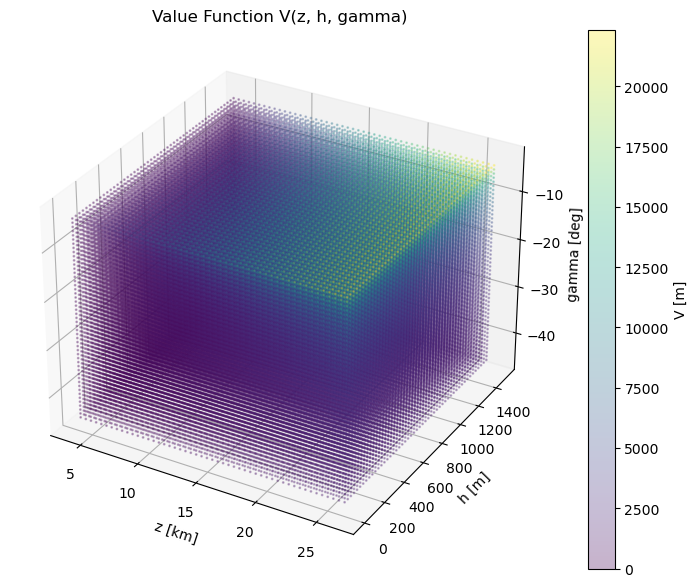

In [34]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

Z_mesh, H_mesh, G_mesh = np.meshgrid(z_grid/1000, h_grid, np.degrees(gamma_grid))

sc = ax.scatter(
    Z_mesh.flatten(),
    H_mesh.flatten(),
    G_mesh.flatten(),
    c=V.flatten(),
    cmap='viridis',
    alpha=0.3,
    s=1
)

plt.colorbar(sc, label='V [m]')
ax.set_xlabel('z [km]')
ax.set_ylabel('h [m]')
ax.set_zlabel('gamma [deg]')
ax.set_title('Value Function V(z, h, gamma)')
plt.show()

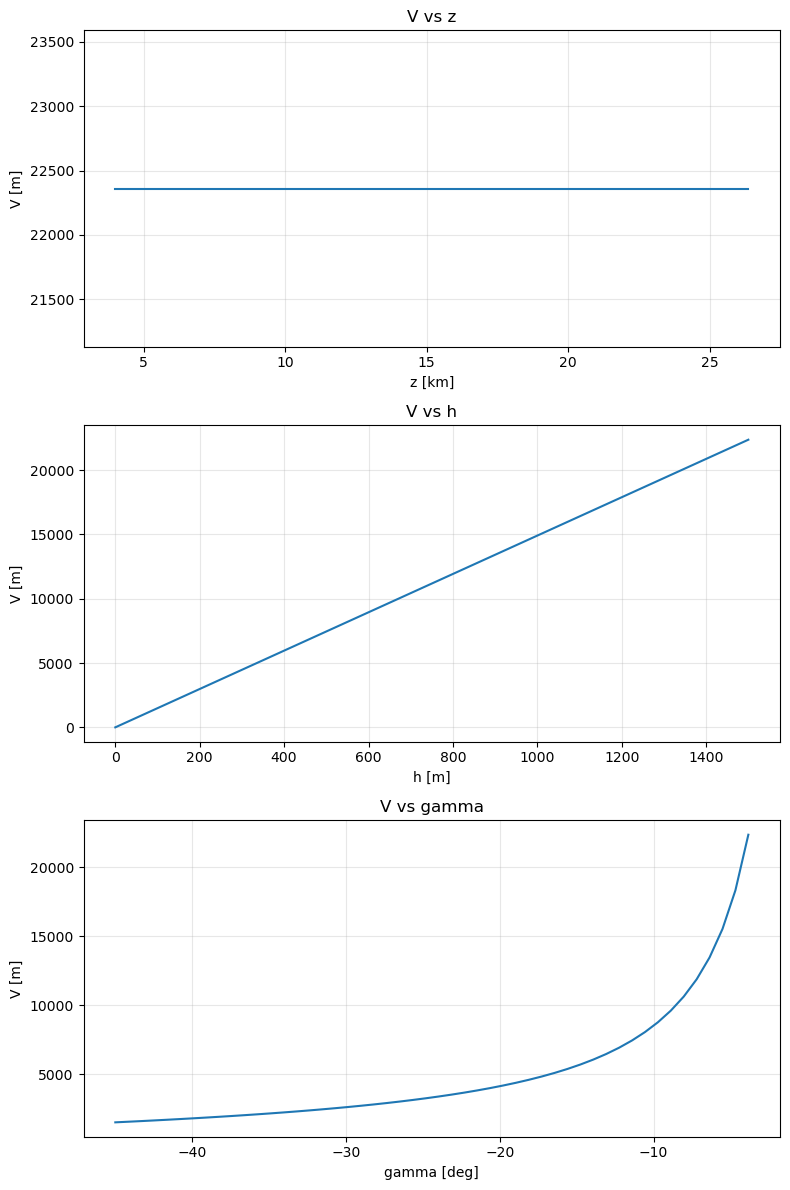

In [35]:
fig, axes = plt.subplots(3, 1, figsize=(8, 12))

# V vs z (max over h and gamma)
axes[0].plot(z_grid/1000, np.max(V, axis=(1,2)))
axes[0].set_xlabel('z [km]')
axes[0].set_ylabel('V [m]')
axes[0].set_title('V vs z')
axes[0].grid(True, alpha=0.3)

# V vs h (max over z and gamma)
axes[1].plot(h_grid, np.max(V, axis=(0,2)))
axes[1].set_xlabel('h [m]')
axes[1].set_ylabel('V [m]')
axes[1].set_title('V vs h')
axes[1].grid(True, alpha=0.3)

# V vs gamma (max over z and h)
axes[2].plot(np.degrees(gamma_grid), np.max(V, axis=(0,1)))
axes[2].set_xlabel('gamma [deg]')
axes[2].set_ylabel('V [m]')
axes[2].set_title('V vs gamma')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [36]:
# Extract optimal trajectory by greedy search from (Z_GOAL, 0)
# At each step, find neighboring cell with minimum cost

# Start at Z_GOAL, h=0
i_z = N_Z - 1
i_h = 0

z_traj = [z_grid[i_z]]
h_traj = [h_grid[i_h]]
gamma_traj = []

while i_h < N_H - 1:  # stop when we reach H_SW
    # Find gamma that maximizes V at current (i_z, i_h)
    i_g_best = np.argmax(V[i_z, i_h, :])
    gamma_traj.append(gamma_grid[i_g_best])

    # Move to next cell
    gamma = gamma_grid[i_g_best]
    v     = glide_speed(gamma)
    dt    = h_grid[i_h] / (v * abs(np.sin(gamma))) if i_h > 0 else dh / (v * abs(np.sin(gamma)))

    z_next = z_grid[i_z] - v * np.cos(abs(gamma)) * dt
    h_next = h_grid[i_h] - v * np.sin(gamma)      * dt

    i_z = int(np.round((z_next - z_grid[0]) / dz))
    i_h = int(np.round((h_next - h_grid[0]) / dh))

    i_z = np.clip(i_z, 0, N_Z - 1)
    i_h = np.clip(i_h, 0, N_H - 1)

    z_traj.append(z_grid[i_z])
    h_traj.append(h_grid[i_h])

print(f'Trajectory extracted: {len(z_traj)} waypoints')
print(f'Start: z={z_traj[0]:.0f}m, h={h_traj[0]:.0f}m')
print(f'End:   z={z_traj[-1]:.0f}m, h={h_traj[-1]:.0f}m')
print(f'gamma mean = {np.degrees(np.mean(gamma_traj)):.4f} deg')
print(f'gamma std  = {np.degrees(np.std(gamma_traj)):.6f} deg')
print(f'gamma*     = {np.degrees(GAMMA_STAR):.4f} deg')

Trajectory extracted: 8 waypoints
Start: z=26365m, h=0m
End:   z=4000m, h=1500m
gamma mean = -9.7181 deg
gamma std  = 14.403781 deg
gamma*     = -3.8378 deg


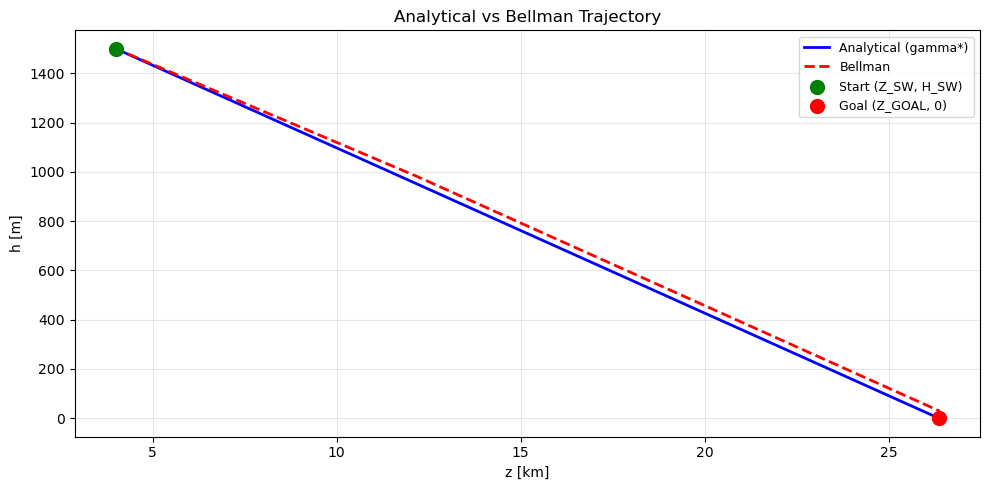

In [37]:
fig, ax = plt.subplots(figsize=(10, 5))

# Analytical
ax.plot(traj_analytial['z']/1000, traj_analytial['h'], 
        'b', lw=2, label='Analytical (gamma*)')

# Bellman
ax.plot(np.array(z_traj)/1000, h_traj, 
        'r--', lw=2, label='Bellman')

# Start and goal
ax.scatter([Z_SW/1000], [H_SW], color='green', s=100, zorder=6, label='Start (Z_SW, H_SW)')
ax.scatter([Z_GOAL/1000], [0], color='red', s=100, zorder=6, label='Goal (Z_GOAL, 0)')

ax.set_xlabel('z [km]')
ax.set_ylabel('h [m]')
ax.set_title('Analytical vs Bellman Trajectory')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

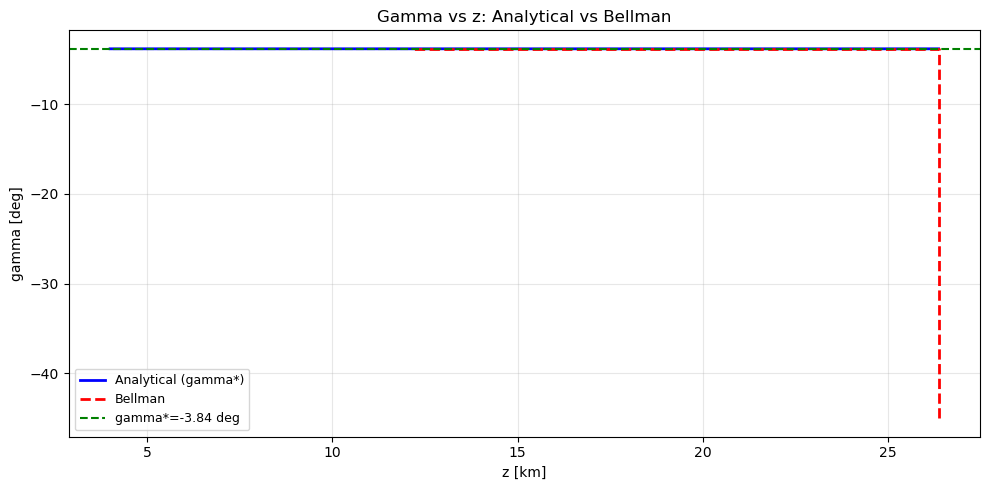

In [38]:
fig, ax = plt.subplots(figsize=(10, 5))

# Analytical
ax.plot(traj_analytial['z']/1000, np.degrees(traj_analytial['gamma']),
        'b', lw=2, label='Analytical (gamma*)')

# Bellman
ax.plot(np.array(z_traj[:-1])/1000, np.degrees(gamma_traj),
        'r--', lw=2, label='Bellman')

ax.axhline(np.degrees(GAMMA_STAR), color='green', ls='--', lw=1.5,
           label=f'gamma*={np.degrees(GAMMA_STAR):.2f} deg')

ax.set_xlabel('z [km]')
ax.set_ylabel('gamma [deg]')
ax.set_title('Gamma vs z: Analytical vs Bellman')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Compare
- discretized Bellman vs MPC vs SAC
- with velocity instantly controllable -> how do we compute exact PDE for HJB?

1. write down continuous HJB this setup is solving
2. simple range-based sensor at goal -> what's the optimal control policy for this